In [1]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import Plotter

ARCH = ['01_mlp_baseline', '02_small_cnn', '03_regularized_cnn', '04_resnet', '05_alexnet', '06_googlenet']
plotter = Plotter(project='fer2013-experiments')
plotter.load(ARCH)
print('loaded:', ARCH)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\User\_netrc.


loaded: ['01_mlp_baseline', '02_small_cnn', '03_regularized_cnn', '04_resnet', '05_alexnet', '06_googlenet']


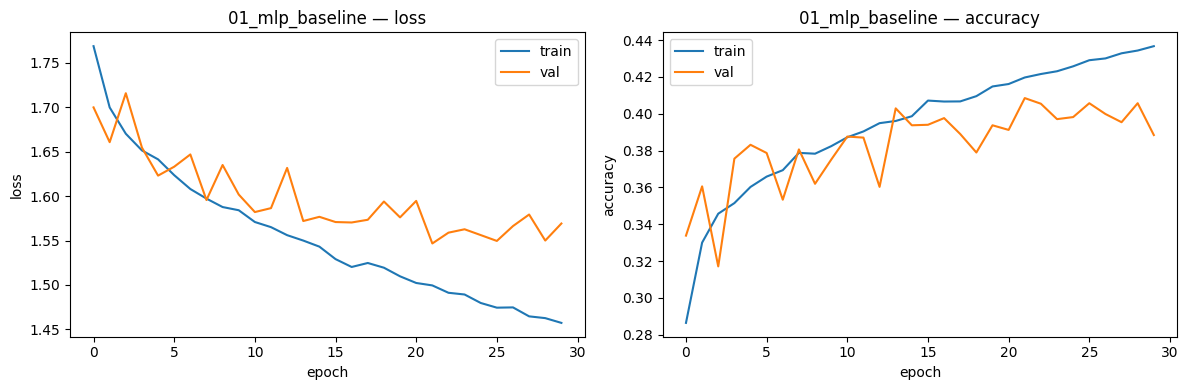

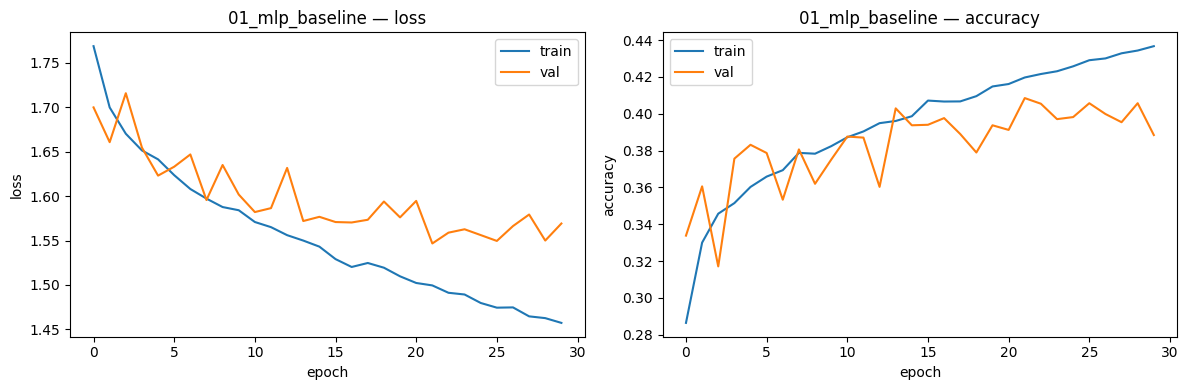

In [2]:
plotter.curves('01_mlp_baseline')

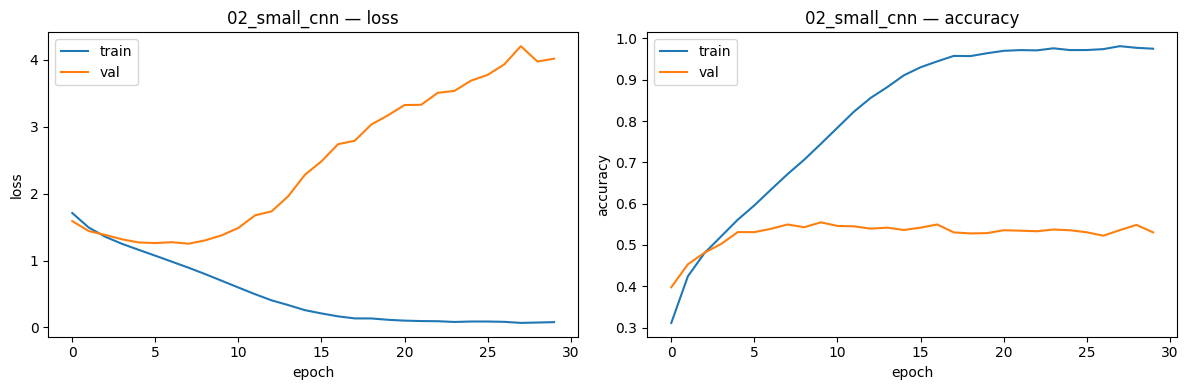

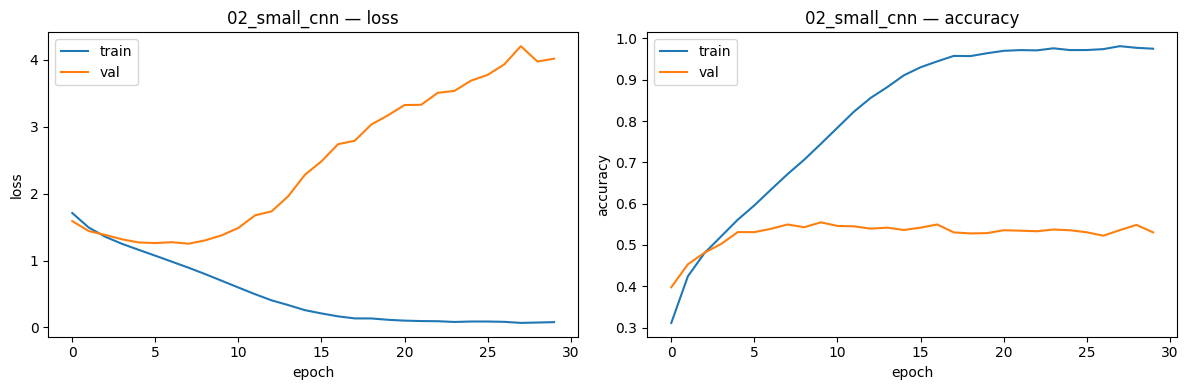

In [3]:
plotter.curves('02_small_cnn')

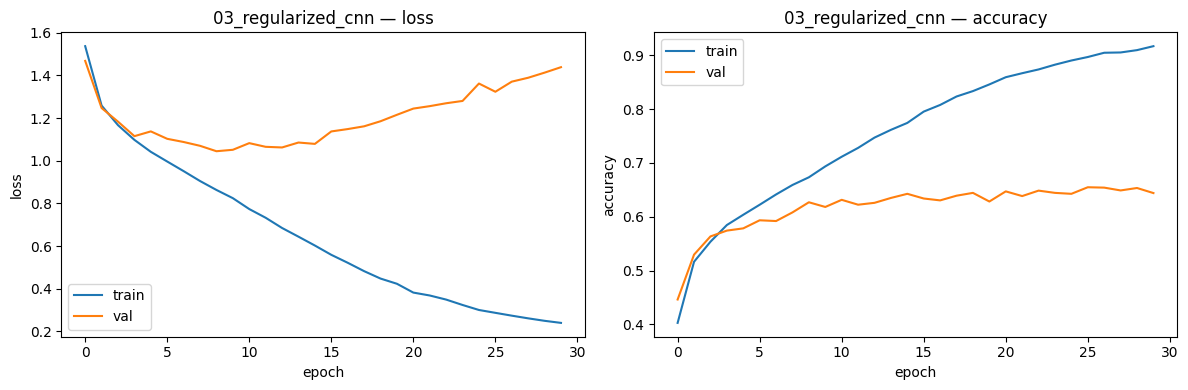

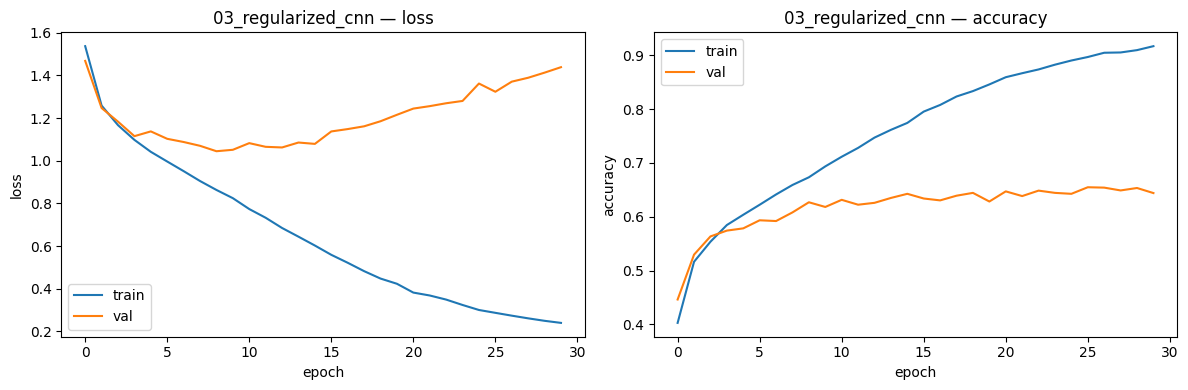

In [4]:
plotter.curves('03_regularized_cnn')

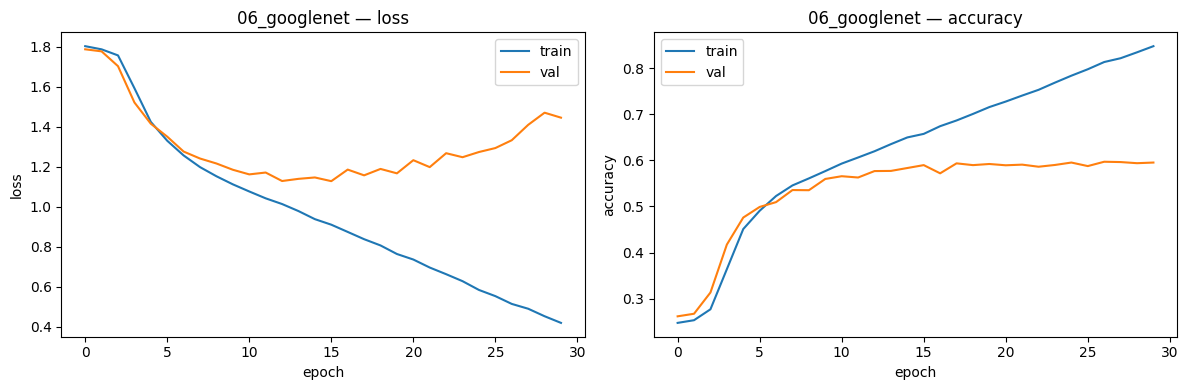

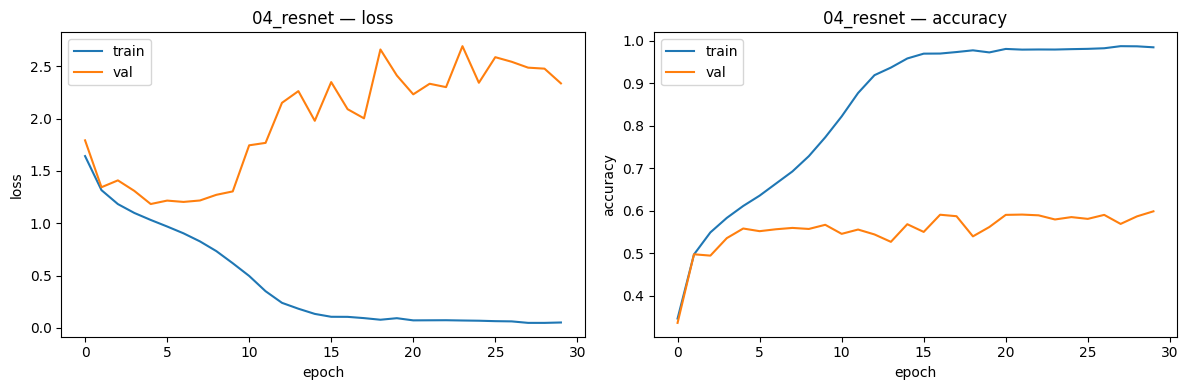

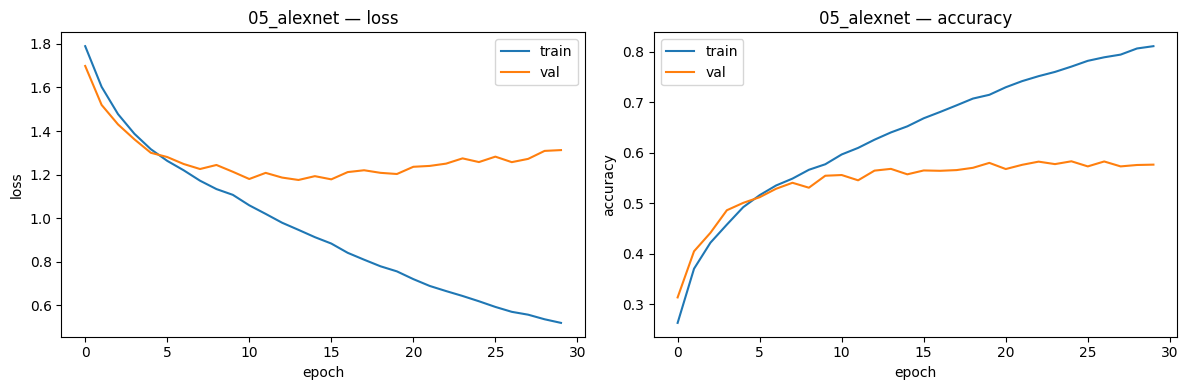

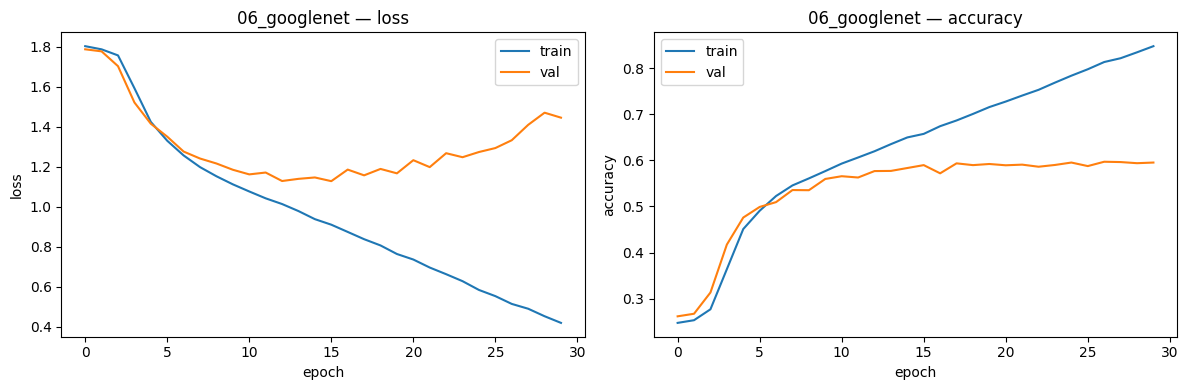

In [5]:
plotter.curves('04_resnet')
plotter.curves('05_alexnet')
plotter.curves('06_googlenet')

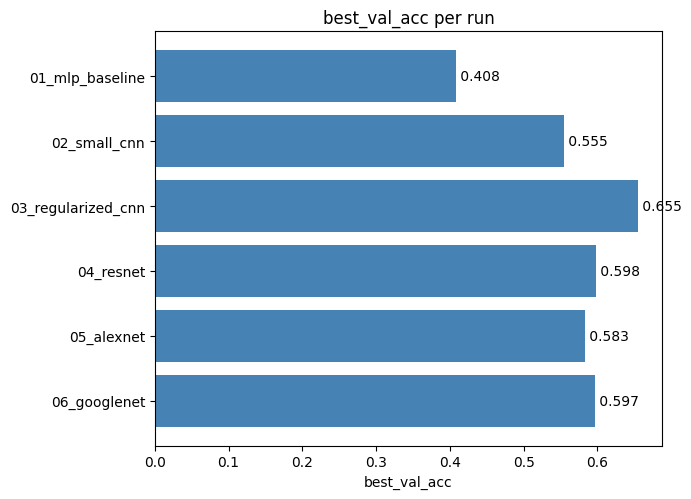

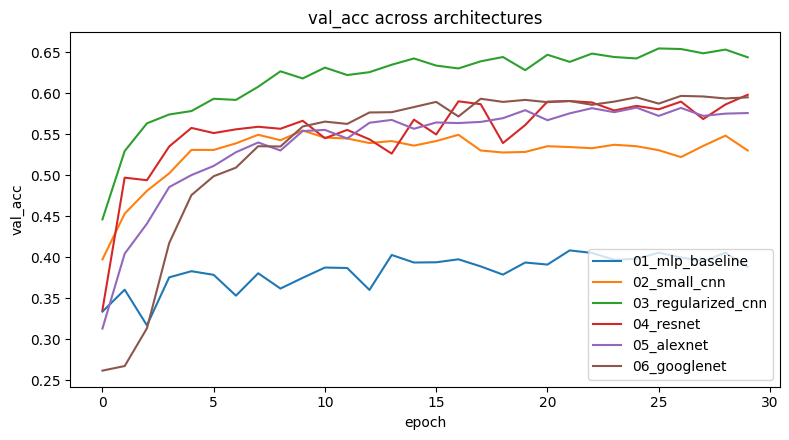

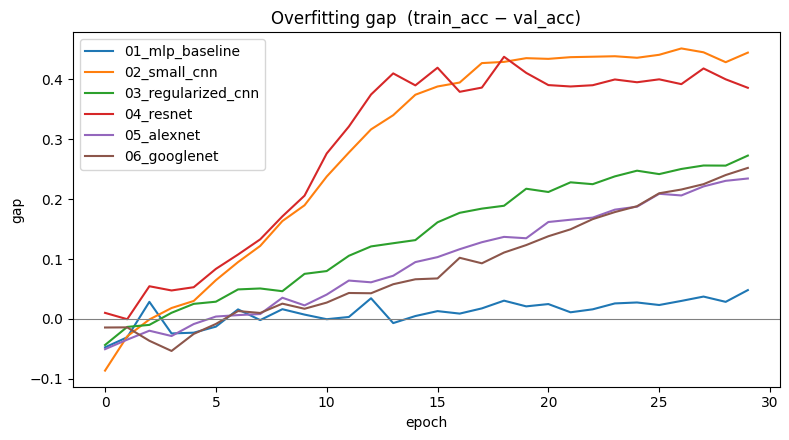

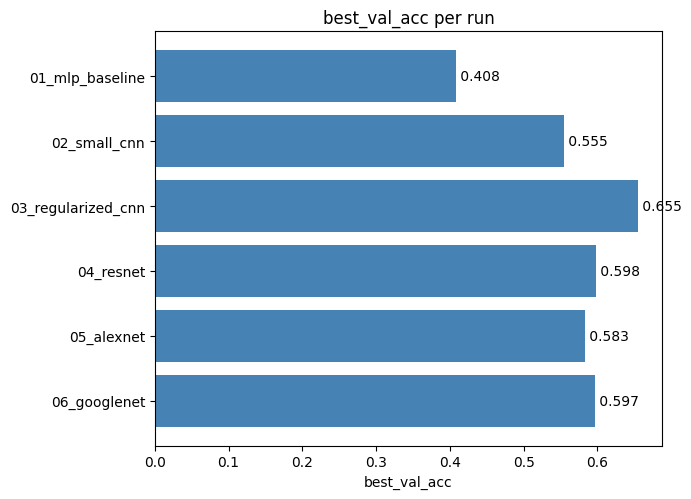

In [6]:
plotter.compare(ARCH, metric='val_acc')
plotter.gap(ARCH)
plotter.best_scores(ARCH)

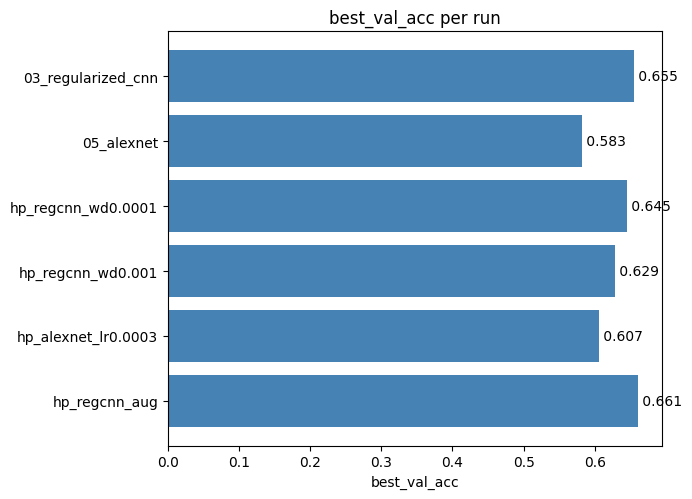

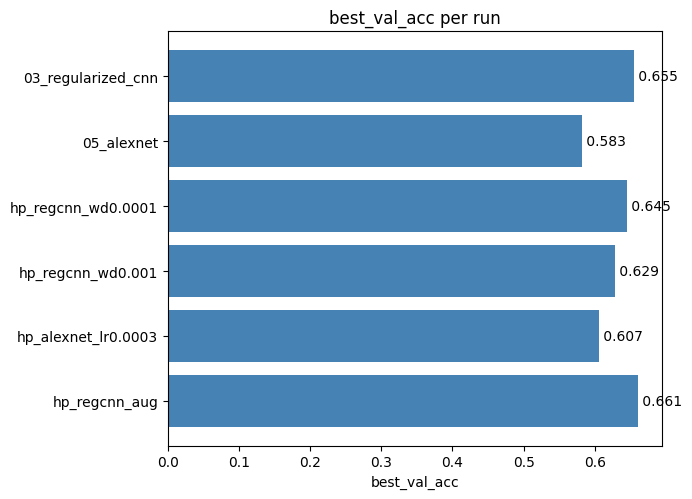

In [7]:
plotter.best_scores(['03_regularized_cnn', 'hp_regcnn_wd0.0001', 'hp_regcnn_wd0.001',
                     'hp_regcnn_aug', '05_alexnet', 'hp_alexnet_lr0.0003'])

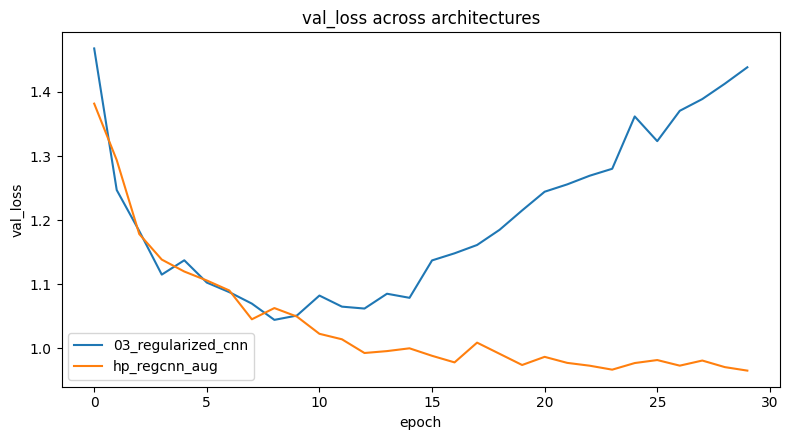

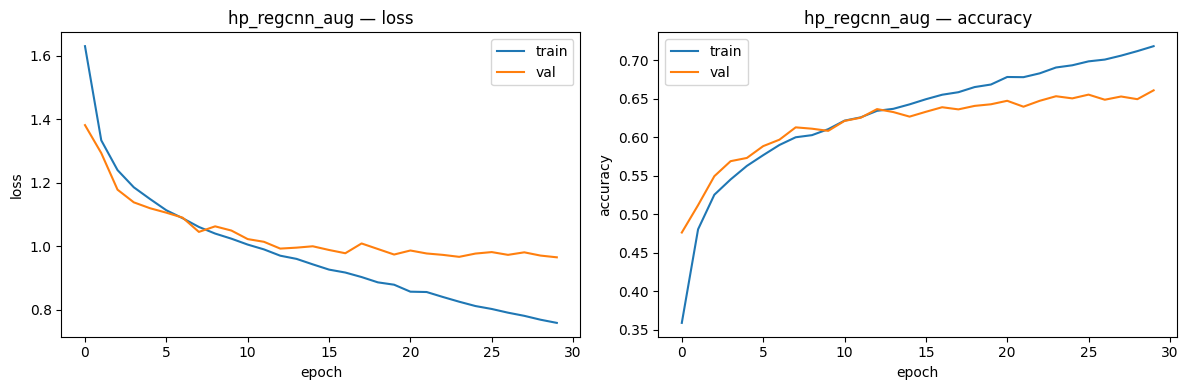

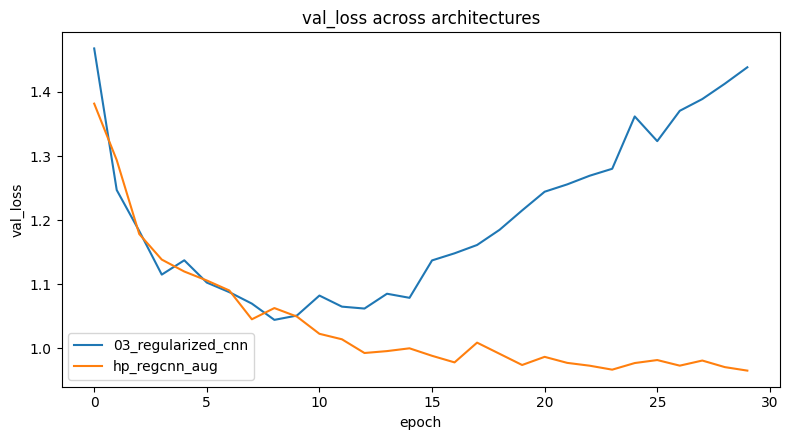

In [8]:
plotter.curves('hp_regcnn_aug')
plotter.compare(['03_regularized_cnn', 'hp_regcnn_aug'], metric='val_loss')

checkpoint: checkpoints/03_regularized_cnn.pt | val acc: 0.6548


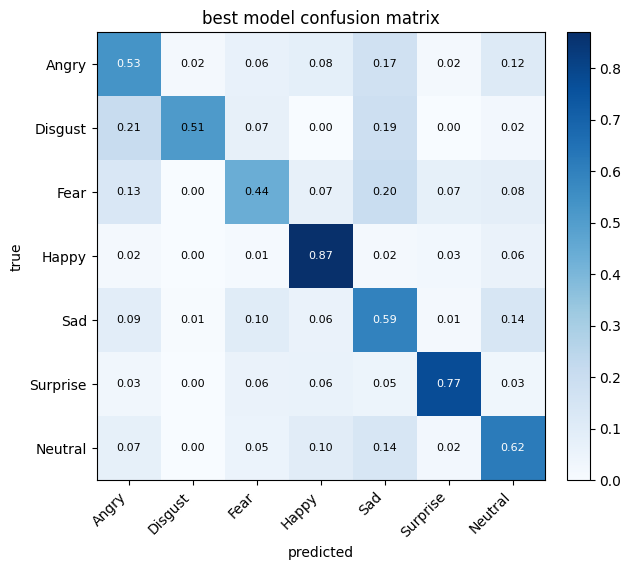

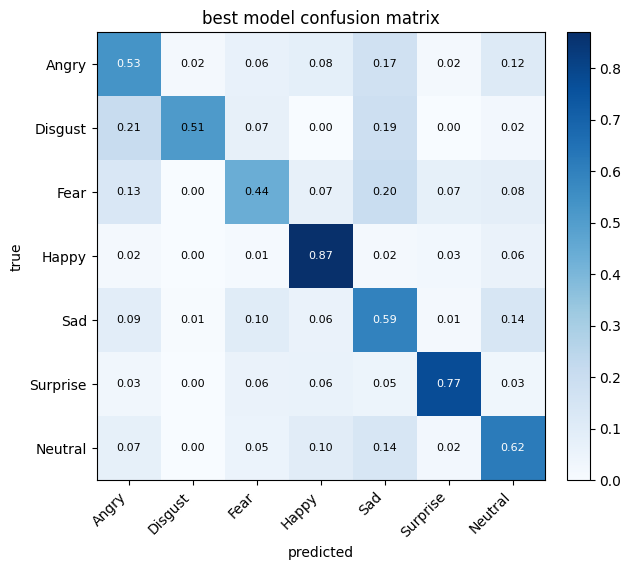

In [9]:
import importlib, os, src.data, src.models, src.train
for _m in (src.data, src.models, src.train):
    importlib.reload(_m)
import torch, torch.nn as nn
from src.data import get_loaders
from src.models import RegularizedCNN
from src.train import evaluate, DEVICE

_, va = get_loaders('../train.csv', batch_size=64)
ckpt = 'checkpoints/hp_regcnn_aug.pt' if os.path.exists('checkpoints/hp_regcnn_aug.pt') else 'checkpoints/03_regularized_cnn.pt'
model = RegularizedCNN().to(DEVICE)
model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
_, acc, preds, ys = evaluate(model, va, nn.CrossEntropyLoss(), return_preds=True)
print('checkpoint:', ckpt, '| val acc:', round(acc, 4))
plotter.confusion(ys, preds, title='best model confusion matrix')